# Brain Tumor MRI Classification - Week 2: Deep Learning Training Pipeline

**Objective:** Build complete preprocessing pipeline, implement CNN baseline, train model, evaluate results, and compare experiments.

**Dataset:** Brain Tumor MRI Dataset on Kaggle
**Duration:** Week 2 of 4-week project  
**Last Updated:** May 2026


## Week 2


## 1. Setup & Environment Configuration

In [16]:
# Set random seeds for reproducibility
import numpy as np
import torch
import random

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    print(f"✓ GPU available: {torch.cuda.get_device_name(0)}")
else:
    print("⚠ GPU not available, using CPU")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

✓ GPU available: Tesla T4
Device: cuda


In [17]:
# Verify core imports
try:
    import numpy as np
    print(f"NumPy {np.__version__}")
except ImportError as e:
    print(f"NumPy import failed: {e}")

try:
    import torch
    print(f"PyTorch {torch.__version__}")
except ImportError as e:
    print(f"PyTorch import failed: {e}")

try:
    from PIL import Image
    print(f"PIL (Pillow)")
except ImportError as e:
    print(f"PIL import failed: {e}")

# Core imports
import os
import glob
from pathlib import Path
from collections import Counter
from PIL import Image
import time

# Data science
import numpy as np
import pandas as pd

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split

# Utilities
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("\nAll core libraries imported successfully")
print(f"  - NumPy: {np.__version__}")
print(f"  - PyTorch: {torch.__version__}")
print(f"  - Pandas: {pd.__version__}")


NumPy 2.0.2
PyTorch 2.10.0+cu128
PIL (Pillow)

All core libraries imported successfully
  - NumPy: 2.0.2
  - PyTorch: 2.10.0+cu128
  - Pandas: 2.2.2


---

## 2. Dataset Configuration

In [18]:
# Optional: Kaggle download helper for Colab (skip on Kaggle)
import os
from pathlib import Path

IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_TPU_ADDR" in os.environ
IN_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IN_COLAB and not IN_KAGGLE:
    kaggle_json_candidates = [
        Path("/content/kaggle.json"),
        Path("/content/drive/MyDrive/kaggle.json"),
    ]
    kaggle_json = next((p for p in kaggle_json_candidates if p.exists()), None)

    if kaggle_json is None:
        print("Colab detected. Upload kaggle.json to /content or /content/drive/MyDrive to enable download.")
    else:
        if not Path("/content/data/raw/Training").exists():
            print("Downloading dataset from Kaggle...")
            !pip -q install kaggle
            !mkdir -p /content/.kaggle
            !cp -f {kaggle_json} /content/.kaggle/kaggle.json
            !chmod 600 /content/.kaggle/kaggle.json
            !kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/data
            !unzip -q /content/data/brain-tumor-mri-dataset.zip -d /content/data/raw
        else:
            print("Dataset already available at /content/data/raw")
else:
    print("Kaggle or local environment detected. No download step required.")

Colab detected. Upload kaggle.json to /content or /content/drive/MyDrive to enable download.


### Manual Dataset Download (without `kaggle.json`)

If you don't have a `kaggle.json` file or prefer to download the dataset manually:

1.  Go to the Kaggle dataset page: `https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset`
2.  Click the 'Download' button to get `brain-tumor-mri-dataset.zip`.
3.  Upload this `.zip` file to your Google Colab environment (e.g., to `/content/` or a location in your mounted Google Drive).
4.  Then, run the following cell to unzip the dataset.

In [19]:
import os
from pathlib import Path

# Define the expected path for the uploaded zip file
zip_file_path = Path('/content/brain-tumor-mri-dataset.zip')

# Define the target extraction directory
extraction_path = Path('/content/data/raw')

if zip_file_path.exists():
    print(f"Found {zip_file_path.name}. Extracting...")
    # Create the target directory if it doesn't exist
    extraction_path.mkdir(parents=True, exist_ok=True)

    # Unzip the file, using -o to overwrite existing files without prompting
    # The -q flag keeps it quiet (no verbose output during extraction)
    !unzip -o -q {zip_file_path} -d {extraction_path}

    # Verify extraction
    if (extraction_path / 'Training').exists():
        print("✓ Dataset extracted successfully to /content/data/raw")
        # Optional: remove the zip file to save space
        # !rm {zip_file_path}
    else:
        print("⚠ Extraction might not have created 'Training' directory as expected.")
else:
    print(f"❌ {zip_file_path.name} not found. Please upload the dataset zip file to /content/")
    print("You can also check if you uploaded it to Google Drive and modify `zip_file_path` accordingly.")

Found brain-tumor-mri-dataset.zip. Extracting...
✓ Dataset extracted successfully to /content/data/raw


In [20]:
# Dataset path resolution (Kaggle / Colab / local)
from pathlib import Path

cwd = Path.cwd()
candidate_roots = [
    Path("/kaggle/input/brain-tumor-mri-dataset"),
    Path("/content/data/raw"),
    cwd / "data/raw",
    cwd.parent / "data/raw",
]

DATA_DIR = next((p for p in candidate_roots if (p / "Training").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Expected Training/Testing under one of: "
        + ", ".join(str(p) for p in candidate_roots)
        + ". On Kaggle, add data 'masoudnickparvar/brain-tumor-mri-dataset'."
    )

train_path = DATA_DIR / "Training"
test_path = DATA_DIR / "Testing"

print("DATA_DIR :", DATA_DIR)
print("Train exists:", train_path.exists())
print("Test  exists:", test_path.exists())

for subset in ("Training", "Testing"):
    p = DATA_DIR / subset
    if p.exists():
        classes_found = sorted([d.name for d in p.iterdir() if d.is_dir()])
        print(f"  {subset}/  ->  {classes_found}")

DATA_DIR : /content/data/raw
Train exists: True
Test  exists: True
  Training/  ->  ['glioma', 'meningioma', 'notumor', 'pituitary']
  Testing/  ->  ['glioma', 'meningioma', 'notumor', 'pituitary']


In [21]:
# ── Configuration ────────────────────────────────────────────────────────────
QUICK_RUN        = False
TRAIN_SUBSET_FRAC = 1.0        # use full training set
IMAGE_SIZE       = 224         # resize target (px)

# ── Epoch choice ─────────────────────────────────────────────────────────────
# With ~10k images, batch_size=32, and a 4-block CNN trained from scratch:
#   - The model typically converges in 20-35 epochs on GPU.
#   - EarlyStopping (patience=10) will stop it early if val_acc plateaus.
#   - Setting MAX_EPOCHS=40 gives headroom without wasting time.
MAX_EPOCHS       = 40
BATCH_SIZE       = 32

# ── Output directories ───────────────────────────────────────────────────────
from pathlib import Path
RESULTS_DIR      = Path("results")
PLOTS_DIR        = RESULTS_DIR / "plots"
MODELS_DIR       = RESULTS_DIR / "models"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"IMAGE_SIZE={IMAGE_SIZE}, MAX_EPOCHS={MAX_EPOCHS}, BATCH_SIZE={BATCH_SIZE}")
print(f"Output dirs: {PLOTS_DIR}/  {MODELS_DIR}/")

IMAGE_SIZE=224, MAX_EPOCHS=40, BATCH_SIZE=32
Output dirs: results/plots/  results/models/


In [22]:
print(f"Config confirmed: IMAGE_SIZE={IMAGE_SIZE}, MAX_EPOCHS={MAX_EPOCHS}, "
      f"BATCH_SIZE={BATCH_SIZE}, PLOTS_DIR={PLOTS_DIR}")


Config confirmed: IMAGE_SIZE=224, MAX_EPOCHS=40, BATCH_SIZE=32, PLOTS_DIR=results/plots


---

## 3. Data Loading

In [23]:
CLASSES     = ['glioma', 'meningioma', 'notumor', 'pituitary']
CLASS_MAP   = {cls_name: i for i, cls_name in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

def collect_image_paths(data_dir, classes):
    """
    Collect all image file paths from the dataset directory.

    Strategy:
        The Kaggle dataset ships with a predefined Training/ Testing/ split.
        We deliberately IGNORE that split and pool ALL images, then apply our
        own stratified 70 / 15 / 15 split.  This gives us full control over
        class balance in every subset and avoids relying on the original
        split's unknown methodology.

    Handles two layouts:
        Layout A: <data_dir>/<class_name>/*.jpg
        Layout B: <data_dir>/{Training,Testing}/<class_name>/*.jpg  ← Kaggle
    """
    image_paths = []
    labels      = []

    for class_name in classes:
        label = CLASS_MAP[class_name]

        # Layout A: flat class folders directly under data_dir
        class_dir = data_dir / class_name
        if class_dir.exists():
            imgs = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
            image_paths.extend(imgs)
            labels.extend([label] * len(imgs))

        # Layout B: nested inside subset folders (Training / Testing)
        for subset in ["Training", "Testing"]:
            sub = data_dir / subset / class_name
            if sub.exists():
                imgs = list(sub.glob("*.jpg")) + list(sub.glob("*.png"))
                image_paths.extend(imgs)
                labels.extend([label] * len(imgs))

    return image_paths, labels

# Collect all images (Training + Testing folders combined)
image_paths, labels = collect_image_paths(Path(DATA_DIR), CLASSES)

print(f"Total images collected: {len(image_paths):,}  (Training + Testing pooled)")
print(f"\nClass distribution:")
import numpy as np
unique_labels, counts = np.unique(labels, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"  {CLASSES[label]:<15}: {count:>5}  ({100*count/len(labels):.1f}%)")


Total images collected: 7,200  (Training + Testing pooled)

Class distribution:
  glioma         :  1800  (25.0%)
  meningioma     :  1800  (25.0%)
  notumor        :  1800  (25.0%)
  pituitary      :  1800  (25.0%)


---

## 4. Data Preprocessing Pipeline

### 4.1 Why Preprocessing Matters

**For Medical MRI Images, preprocessing is critical because:**

1. **Normalization:** MRI pixel values vary by scanner manufacturer and imaging parameters. Normalizing to [-1, 1] or [0, 1] ensures:
   - Consistent input distribution across all images
   - Faster convergence during training
   - Improved gradient flow in neural networks

2. **Resizing:** 512×512 images require massive memory. Resizing to 224×224:
   - Reduces memory usage by 20x
   - Matches standard CNN architectures (ResNet, VGG, etc.)
   - Maintains sufficient spatial resolution for tumor detection

3. **Label Encoding:** Convert class names → numerical indices for PyTorch

### 4.2 Augmentation Strategy

**Data augmentation improves generalization by:**

- **Rotation (±20°):** Tumors can appear at different angles in brain scans
- **Horizontal Flip:** MRI symmetry allows left-right mirroring
- **Brightness/Contrast:** Accounts for imaging parameter variations
- **Random Crop:** Forces model to learn features at different scales

**Why this matters in medical imaging:**
- Increases effective dataset size without collecting more data
- Makes model robust to real-world imaging variations
- Reduces overfitting on limited medical data

In [24]:
# ── Preprocessing transforms ─────────────────────────────────────────────────
# transforms.ToTensor():
#   • Converts PIL Image (H×W×C uint8) → float32 Tensor (C×H×W) in [0, 1]
#   • Returns a writable, contiguous tensor  (no undefined-behavior warnings)
#   • Works identically on CPU, CUDA, and Kaggle's TPU VMs
# Why NOT the custom PILToFloatTensorNoNumpy?
#   torch.ByteStorage / TypedStorage are deprecated since PyTorch 2.0 and
#   fully removed in 2.3; the custom class fires a UserWarning-as-error on
#   modern Kaggle kernels and will break in future PyTorch releases.

# TRAIN  ── with augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),           # 512×512 → 224×224
    transforms.RandomRotation(20),                          # ±20° rotation
    transforms.RandomHorizontalFlip(p=0.5),                # 50 % flip
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # scanner variation
    transforms.ToTensor(),                                  # PIL → float32 [0,1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),             # [0,1] → [-1,1]
])

# VAL / TEST  ── deterministic only
val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

print("✓ Transform pipelines defined")
print(f"\n  Train  : Resize → Rotation ±20° → HFlip → ColorJitter → ToTensor → Normalize")
print(f"  Val/Test: Resize → ToTensor → Normalize")


✓ Transform pipelines defined

  Train  : Resize → Rotation ±20° → HFlip → ColorJitter → ToTensor → Normalize
  Val/Test: Resize → ToTensor → Normalize


### 4.3 Custom PyTorch Dataset Class

In [25]:
class BrainMRIDataset(Dataset):
    """
    Custom PyTorch Dataset for Brain Tumor MRI images.

    Args:
        image_paths: List[Path] – paths to image files
        labels: List[int]       – integer class indices
        transform: Composed torchvision transforms
    """
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image and convert to RGB (handles grayscale + palette images)
        img   = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]

        # Apply transforms: Resize → (Aug) → ToTensor → Normalize
        if self.transform is not None:
            img = self.transform(img)

        return img, label

print("BrainMRIDataset class defined")
print("  - Uses torchvision transforms pipeline")
print("  - Handles both grayscale and RGB images")
print("  - Compatible with train/val/test transform setup")

BrainMRIDataset class defined
  - Uses torchvision transforms pipeline
  - Handles both grayscale and RGB images
  - Compatible with train/val/test transform setup


### 4.4 Train/Val/Test Split

In [26]:
# Split dataset: 70% train, 15% val, 15% test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, random_state=SEED, stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f"Dataset split:")
print(f"  Training:   {len(train_paths):>5} images (70%)")
print(f"  Validation: {len(val_paths):>5} images (15%)")
print(f"  Testing:    {len(test_paths):>5} images (15%)")
print(f"  Total:      {len(image_paths):>5} images")

# Verify stratification
print(f"\n✓ Stratified split (verified):")
for split_name, split_labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    unique, counts = np.unique(split_labels, return_counts=True)
    print(f"  {split_name}:", {CLASSES[idx]: count for idx, count in zip(unique, counts)})

Dataset split:
  Training:    5040 images (70%)
  Validation:  1080 images (15%)
  Testing:     1080 images (15%)
  Total:       7200 images

✓ Stratified split (verified):
  Train: {'glioma': np.int64(1260), 'meningioma': np.int64(1260), 'notumor': np.int64(1260), 'pituitary': np.int64(1260)}
  Val: {'glioma': np.int64(270), 'meningioma': np.int64(270), 'notumor': np.int64(270), 'pituitary': np.int64(270)}
  Test: {'glioma': np.int64(270), 'meningioma': np.int64(270), 'notumor': np.int64(270), 'pituitary': np.int64(270)}


### 4.5 Create DataLoaders

In [27]:
# Verify environment and create DataLoaders (Kaggle/local)
print("Dependency Check:")
print(f"  NumPy version: {np.__version__}")
print(f"  PyTorch version: {torch.__version__}")
print(f"  PIL version: {__import__('PIL').__version__}")
print("All dependencies available\n")

# Create datasets (full training data by default)
train_paths_subset = train_paths
train_labels_subset = train_labels

print("Creating datasets...")
train_dataset = BrainMRIDataset(train_paths_subset, train_labels_subset, transform=train_transform)
val_dataset = BrainMRIDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = BrainMRIDataset(test_paths, test_labels, transform=val_test_transform)
print(f"Datasets created ({len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test)")

# Tune DataLoader settings for the current environment
# BATCH_SIZE already set in config cell; no override needed
NUM_WORKERS = 0 if DEVICE.type == 'cpu' else 2
PIN_MEMORY = DEVICE.type == 'cuda'

print(f"\nCreating DataLoaders (batch_size={BATCH_SIZE}, num_workers={NUM_WORKERS}, pin_memory={PIN_MEMORY})...")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("DataLoaders created successfully")
print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

print("\nTesting DataLoader...")
try:
    sample_batch, sample_labels = next(iter(train_loader))
    print(f"  Sample batch shape: {sample_batch.shape}")
    print(f"  Sample labels shape: {sample_labels.shape}")
    print(f"  Batch min value: {sample_batch.min():.3f}")
    print(f"  Batch max value: {sample_batch.max():.3f}")
    print("DataLoader working correctly!")
except Exception as e:
    print(f"DataLoader error: {e}")
    print("Check transform pipeline and dataset paths.")

Dependency Check:
  NumPy version: 2.0.2
  PyTorch version: 2.10.0+cu128
  PIL version: 11.3.0
All dependencies available

Creating datasets...
Datasets created (5040 train, 1080 val, 1080 test)

Creating DataLoaders (batch_size=32, num_workers=2, pin_memory=True)...
DataLoaders created successfully
  Training batches: 158
  Validation batches: 34
  Test batches: 34

Testing DataLoader...
  Sample batch shape: torch.Size([32, 3, 224, 224])
  Sample labels shape: torch.Size([32])
  Batch min value: -1.000
  Batch max value: 1.000
DataLoader working correctly!


---

## 5. CNN Baseline Model Architecture

### 5.1 Architecture Design

**Simple CNN for Brain Tumor Classification:**

```
Input: 3 × 224 × 224 (RGB image)
  ↓
Conv Block 1: 32 filters, 3×3 kernel → BatchNorm → ReLU → MaxPool(2×2)
  ↓ Output: 32 × 112 × 112
Conv Block 2: 64 filters, 3×3 kernel → BatchNorm → ReLU → MaxPool(2×2)
  ↓ Output: 64 × 56 × 56
Conv Block 3: 128 filters, 3×3 kernel → BatchNorm → ReLU → MaxPool(2×2)
  ↓ Output: 128 × 28 × 28
Conv Block 4: 256 filters, 3×3 kernel → BatchNorm → ReLU → MaxPool(2×2)
  ↓ Output: 256 × 14 × 14
Global Average Pooling
  ↓ Output: 256
Dense Layer: 512 units → ReLU → Dropout(0.5)
  ↓
Output: 4 classes (softmax)
```

**Total Parameters:** ~6.7M

**Why this architecture?**
- 4 convolutional blocks extract increasingly abstract features
- Batch normalization stabilizes training
- Max pooling reduces spatial dimensions while preserving important features
- Global average pooling prevents overfitting
- Dropout in dense layer reduces overfitting

In [28]:
class BrainTumorCNN(nn.Module):
    """
    Convolutional Neural Network for brain tumor classification.

    Architecture: 4 convolutional blocks + global average pooling + FC layers
    """
    def __init__(self, num_classes=4, dropout_rate=0.5):
        super(BrainTumorCNN, self).__init__()

        # Conv Block 1: 3 → 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv Block 2: 32 → 64
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv Block 3: 64 → 128
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv Block 4: 128 → 256
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU(inplace=True)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Global Average Pooling
        self.global_avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully Connected Layers
        self.fc1 = nn.Linear(256, 512)
        self.fc1_relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Conv Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        # Conv Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        # Conv Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        # Conv Block 4
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.pool4(x)

        # Global Average Pooling
        x = self.global_avgpool(x)
        x = x.view(x.size(0), -1)  # Flatten

        # Fully Connected
        x = self.fc1(x)
        x = self.fc1_relu(x)
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# Create model
model = BrainTumorCNN(num_classes=len(CLASSES), dropout_rate=0.5).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model created: BrainTumorCNN")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Device: {DEVICE}")

✓ Model created: BrainTumorCNN
  Total parameters: 523,012
  Trainable parameters: 523,012
  Device: cuda


In [29]:
# ── Verify model output shape ─────────────────────────────────────────────────
# Run a single forward pass with a dummy batch to confirm tensor dimensions
# and catch architecture bugs before training starts.
model_check = BrainTumorCNN(num_classes=NUM_CLASSES, dropout_rate=0.5).to(DEVICE)
dummy_input = torch.zeros(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)  # batch of 2
with torch.no_grad():
    dummy_output = model_check(dummy_input)

assert dummy_output.shape == (2, NUM_CLASSES),     f"Expected (2, {NUM_CLASSES}), got {dummy_output.shape}"
del model_check, dummy_input, dummy_output

print(f"✓ Forward pass verified: output shape = (batch_size, {NUM_CLASSES})")
print(f"  Input:  (2, 3, {IMAGE_SIZE}, {IMAGE_SIZE})")
print(f"  Output: (2, {NUM_CLASSES})  ← one logit per class, no softmax (CrossEntropyLoss handles it)")


✓ Forward pass verified: output shape = (batch_size, 4)
  Input:  (2, 3, 224, 224)
  Output: (2, 4)  ← one logit per class, no softmax (CrossEntropyLoss handles it)


---

## 6. Training Configuration

In [30]:
NUM_EPOCHS = MAX_EPOCHS
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5

criterion = nn.CrossEntropyLoss()

print(f"Training configuration set (NUM_EPOCHS={NUM_EPOCHS}, BATCH_SIZE={BATCH_SIZE})")
print(f"\n  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  LR scheduler: StepLR (step=15, gamma=0.5)")

Training configuration set (NUM_EPOCHS=40, BATCH_SIZE=32)

  Epochs: 40
  Learning rate: 0.001
  Weight decay: 1e-05
  LR scheduler: StepLR (step=15, gamma=0.5)


In [31]:
# Instantiate model, optimizer, and LR scheduler
# (model class was defined above; hyperparameters set in the cell just before this one)

model = BrainTumorCNN(num_classes=len(CLASSES), dropout_rate=0.5).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)

# Count parameters
total_params      = sum(p.numel() for p in model.parameters())
trainable_params  = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✓ Model, optimizer, and scheduler ready")
print(f"  Model      : BrainTumorCNN  ({total_params:,} parameters)")
print(f"  Optimizer  : Adam  (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  Scheduler  : StepLR  (step_size=15, gamma=0.5)")
print(f"  Device     : {DEVICE}")


✓ Model, optimizer, and scheduler ready
  Model      : BrainTumorCNN  (523,012 parameters)
  Optimizer  : Adam  (lr=0.001, weight_decay=1e-05)
  Scheduler  : StepLR  (step_size=15, gamma=0.5)
  Device     : cuda


---

## 7. Training Loop Implementation

In [32]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train model for one epoch.

    Args:
        model: Neural network model
        train_loader: DataLoader for training data
        criterion: Loss function
        optimizer: Optimization algorithm
        device: GPU or CPU

    Returns:
        avg_loss: Average training loss
        accuracy: Training accuracy
    """
    model.train()  # Set to training mode
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        # Move to device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()  # Clear gradients
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights

        # Track metrics
        total_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

def validate(model, val_loader, criterion, device):
    """
    Validate model on validation set.
    """
    model.eval()  # Set to evaluation mode
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient computation
        for images, labels in tqdm(val_loader, desc="Validating", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(val_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

print("✓ Training functions defined")

✓ Training functions defined


---

## 8. Train Baseline Model

In [33]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
patience_counter = 0
patience = 10

print("\n" + "="*80)
print("TRAINING BASELINE CNN MODEL")
print("="*80)

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:6.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:6.2f}%")

    # ── Callbacks ───────────────────────────────────────────────────────────
    # ModelCheckpoint: save whenever validation accuracy improves
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch'           : epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'         : val_acc,
        }, MODELS_DIR / 'best_model.pth')
    else:
        # EarlyStopping: stop if no improvement for `patience` epochs
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⚠ Early stopping at epoch {epoch+1} "
                  f"(no improvement for {patience} epochs)")
            break

training_time = time.time() - start_time

print("\n" + "="*80)
print(f"Training completed in {training_time:.1f} seconds ({training_time/60:.1f} minutes)")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print("="*80)


TRAINING BASELINE CNN MODEL


Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validating:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch [ 1/40] | Train Loss: 0.9163, Train Acc:  60.99% | Val Loss: 2.2274, Val Acc:  48.24%


Training:   0%|          | 0/158 [00:00<?, ?it/s]

...

Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validating:   0%|          | 0/34 [00:00<?, ?it/s]

Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validating:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch [40/40] | Train Loss: 0.2279, Train Acc:  91.81% | Val Loss: 0.2186, Val Acc:  92.78%

Training completed in 1404.9 seconds (23.4 minutes)
Best validation accuracy: 92.78%


### 8.1 Training History Visualization

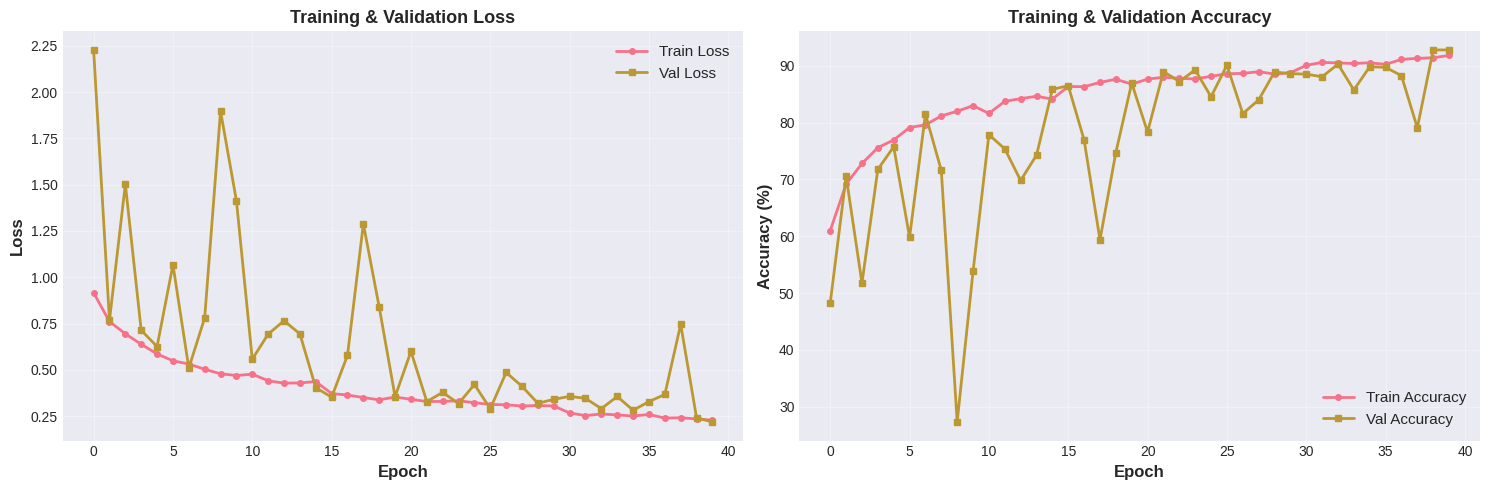

✓ Training curves saved → results/plots/training_curves.png

 Final Results:
  Training Accuracy: 91.81%
  Validation Accuracy: 92.78%
  Train-Val Gap: 0.97%


In [34]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=4)
ax1.plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2, markersize=4)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, markersize=4)
ax2.plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2, markersize=4)
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11, loc='lower right')
ax2.grid(alpha=0.3)

plt.tight_layout()
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOTS_DIR / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✓ Training curves saved → {PLOTS_DIR / "training_curves.png"}')

print(f"\n Final Results:")
print(f"  Training Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Validation Accuracy: {history['val_acc'][-1]:.2f}%")
print(f"  Train-Val Gap: {abs(history['train_acc'][-1] - history['val_acc'][-1]):.2f}%")

---

## 9. Model Evaluation on Test Set

In [35]:
def evaluate_model(model, test_loader, device, classes):
    """
    Evaluate model on test set.
    """
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predicted = outputs.argmax(dim=1)

            # Avoid tensor.numpy() due to disabled Torch<->NumPy bridge in this environment
            all_predictions.extend(predicted.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_predictions)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': conf_matrix,
        'predictions': all_predictions,
        'labels': all_labels
    }

# Evaluate baseline
results_baseline = evaluate_model(model, test_loader, DEVICE, CLASSES)

print("\n" + "="*80)
print("BASELINE MODEL - TEST SET EVALUATION")
print("="*80)
print(f"\nOverall Metrics:")
print(f"  Accuracy:  {results_baseline['accuracy']*100:.2f}%")
print(f"  Precision: {results_baseline['precision']*100:.2f}%")
print(f"  Recall:    {results_baseline['recall']*100:.2f}%")
print(f"  F1-Score:  {results_baseline['f1']*100:.2f}%")

Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]


BASELINE MODEL - TEST SET EVALUATION

Overall Metrics:
  Accuracy:  92.31%
  Precision: 92.57%
  Recall:    92.31%
  F1-Score:  92.30%


### 9.1 Confusion Matrix

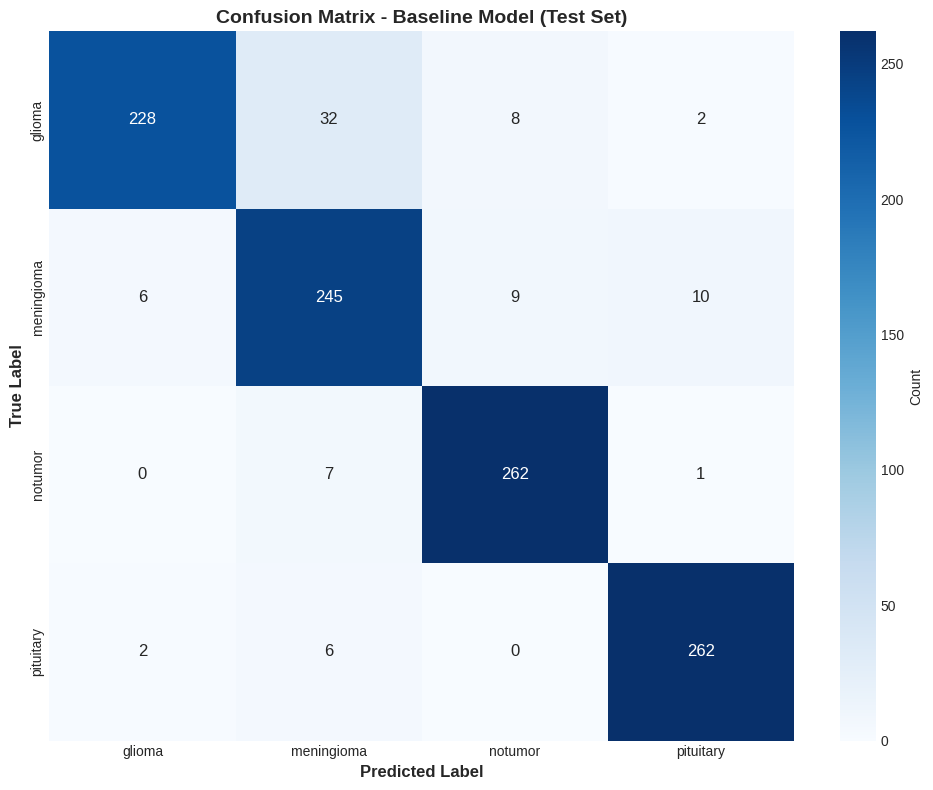

✓ Confusion matrix saved → results/plots/confusion_matrix.png
✓ Confusion matrix generated


In [36]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

conf_matrix = results_baseline['confusion_matrix']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Baseline Model (Test Set)', fontsize=14, fontweight='bold')

plt.tight_layout()
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOTS_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✓ Confusion matrix saved → {PLOTS_DIR / "confusion_matrix.png"}')

print('✓ Confusion matrix generated')

### 9.2 Per-Class Performance

In [37]:
# Classification report
print("\n" + "="*80)
print("PER-CLASS PERFORMANCE")
print("="*80)
print(classification_report(results_baseline['labels'], results_baseline['predictions'],
                          target_names=CLASSES, digits=4))

# Per-class accuracy
conf_matrix = results_baseline['confusion_matrix']
per_class_accuracy = conf_matrix.diagonal() / conf_matrix.sum(axis=1)

print("\nPer-Class Accuracy:")
for class_name, acc in zip(CLASSES, per_class_accuracy):
    print(f"  {class_name:<15}: {acc*100:>6.2f}%")


PER-CLASS PERFORMANCE
              precision    recall  f1-score   support

      glioma     0.9661    0.8444    0.9012       270
  meningioma     0.8448    0.9074    0.8750       270
     notumor     0.9391    0.9704    0.9545       270
   pituitary     0.9527    0.9704    0.9615       270

    accuracy                         0.9231      1080
   macro avg     0.9257    0.9231    0.9230      1080
weighted avg     0.9257    0.9231    0.9230      1080


Per-Class Accuracy:
  glioma         :  84.44%
  meningioma     :  90.74%
  notumor        :  97.04%
  pituitary      :  97.04%


---

## 10. Overfitting Analysis

### What is Overfitting?

**Overfitting** occurs when a model learns training data too well, including noise and peculiarities, and fails to generalize to new data.

**How to detect overfitting:**
- Large gap between training and validation accuracy (>5-10%)
- Training loss continues decreasing while validation loss plateaus or increases
- High training accuracy but low validation accuracy

**How to reduce overfitting:**
1. Increase training data (more augmentation)
2. Add regularization (dropout, L2 weight decay)
3. Simplify model architecture
4. Early stopping based on validation loss

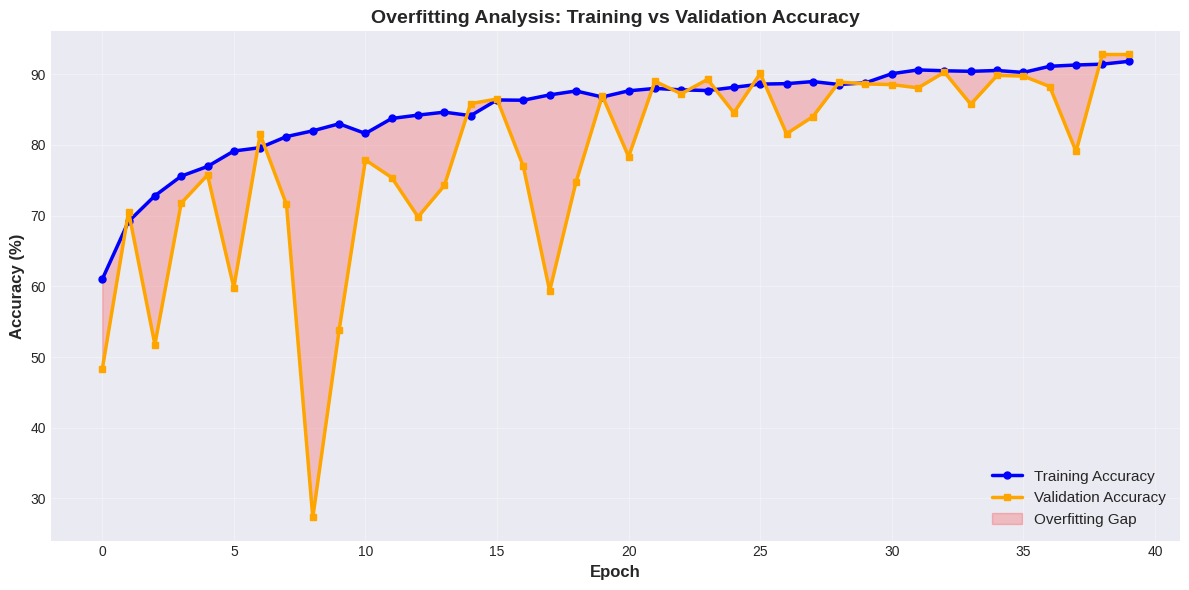


OVERFITTING ANALYSIS

Final Training Accuracy: 91.81%
Final Validation Accuracy: 92.78%
Train-Val Gap: -0.97%
Max Gap (any epoch): 54.67%
Average Gap: 6.93%

✓ MINIMAL OVERFITTING: Model generalizes well


In [38]:
# Analyze overfitting
fig, ax = plt.subplots(figsize=(12, 6))

train_acc = np.array(history['train_acc'])
val_acc = np.array(history['val_acc'])
gap = train_acc - val_acc

ax.plot(train_acc, label='Training Accuracy', marker='o', linewidth=2.5, markersize=5, color='blue')
ax.plot(val_acc, label='Validation Accuracy', marker='s', linewidth=2.5, markersize=5, color='orange')
ax.fill_between(range(len(train_acc)), train_acc, val_acc, alpha=0.2, color='red', label='Overfitting Gap')

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Overfitting Analysis: Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("OVERFITTING ANALYSIS")
print("="*80)
print(f"\nFinal Training Accuracy: {train_acc[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1]:.2f}%")
print(f"Train-Val Gap: {gap[-1]:.2f}%")
print(f"Max Gap (any epoch): {gap.max():.2f}%")
print(f"Average Gap: {gap.mean():.2f}%")

if gap[-1] < 5:
    print("\n✓ MINIMAL OVERFITTING: Model generalizes well")
elif gap[-1] < 10:
    print("\n⚠ MODERATE OVERFITTING: Consider regularization")
else:
    print("\n❌ SEVERE OVERFITTING: Need stronger regularization")

---

## 11. Comparison Experiment: WITH vs WITHOUT Augmentation

### Experiment Design

**Objective:** Compare model performance with and without data augmentation

**Hypothesis:** Data augmentation improves validation accuracy and reduces overfitting

**Setup:**
- **Model 1 (Baseline):** With augmentation (already trained above) ✓
- **Model 2 (NoAug):** Without augmentation (train now) →

**Why this experiment matters:**
- Demonstrates impact of augmentation in medical imaging
- Shows practical benefit of preprocessing strategy
- Validates Week 2 implementation

In [39]:
print("\n" + "="*80)
print("EXPERIMENT: WITH vs WITHOUT DATA AUGMENTATION")
print("="*80)

print("\nModel 2: Training WITHOUT augmentation...\n")

# Create new model WITHOUT augmentation
model_no_aug = BrainTumorCNN(num_classes=len(CLASSES), dropout_rate=0.5).to(DEVICE)
optimizer_no_aug = optim.Adam(model_no_aug.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler_no_aug = optim.lr_scheduler.StepLR(optimizer_no_aug, step_size=15, gamma=0.5)

# Create datasets WITHOUT augmentation
train_dataset_no_aug = BrainMRIDataset(train_paths, train_labels, transform=val_test_transform)
train_loader_no_aug = DataLoader(
    train_dataset_no_aug, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=False
)

# Training history
history_no_aug = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc_no_aug = 0.0
patience_counter_no_aug = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model_no_aug, train_loader_no_aug, criterion, optimizer_no_aug, DEVICE)
    val_loss, val_acc = validate(model_no_aug, val_loader, criterion, DEVICE)
    scheduler_no_aug.step()

    history_no_aug['train_loss'].append(train_loss)
    history_no_aug['train_acc'].append(train_acc)
    history_no_aug['val_loss'].append(val_loss)
    history_no_aug['val_acc'].append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | Val Acc: {val_acc:6.2f}%")

    # Early stopping
    if val_acc > best_val_acc_no_aug:
        best_val_acc_no_aug = val_acc
        patience_counter_no_aug = 0
    else:
        patience_counter_no_aug += 1
        if patience_counter_no_aug >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print("\n✓ Model training completed (NO augmentation)")


EXPERIMENT: WITH vs WITHOUT DATA AUGMENTATION

Model 2: Training WITHOUT augmentation...



Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validating:   0%|          | 0/34 [00:00<?, ?it/s]

Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validating:   0%|          | 0/34 [00:00<?, ?it/s]

...

Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validating:   0%|          | 0/34 [00:00<?, ?it/s]

Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validating:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch [40/40] | Val Acc:  60.00%

✓ Model training completed (NO augmentation)


### 11.1 Evaluate Model WITHOUT Augmentation

In [40]:
# Evaluate model without augmentation
results_no_aug = evaluate_model(model_no_aug, test_loader, DEVICE, CLASSES)

print("\n" + "="*80)
print("MODEL WITHOUT AUGMENTATION - TEST SET EVALUATION")
print("="*80)
print(f"\n📊 Overall Metrics:")
print(f"  Accuracy:  {results_no_aug['accuracy']*100:.2f}%")
print(f"  Precision: {results_no_aug['precision']*100:.2f}%")
print(f"  Recall:    {results_no_aug['recall']*100:.2f}%")
print(f"  F1-Score:  {results_no_aug['f1']*100:.2f}%")

Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]


MODEL WITHOUT AUGMENTATION - TEST SET EVALUATION

📊 Overall Metrics:
  Accuracy:  55.93%
  Precision: 83.11%
  Recall:    55.93%
  F1-Score:  54.59%


### 11.2 Comparison Results Table

In [41]:
# Create comparison table
comparison_data = {
    'Metric': ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score',
               'Train Acc (final)', 'Val Acc (final)', 'Train-Val Gap'],
    'WITH Augmentation': [
        f"{results_baseline['accuracy']*100:.2f}%",
        f"{results_baseline['precision']*100:.2f}%",
        f"{results_baseline['recall']*100:.2f}%",
        f"{results_baseline['f1']*100:.2f}%",
        f"{history['train_acc'][-1]:.2f}%",
        f"{history['val_acc'][-1]:.2f}%",
        f"{abs(history['train_acc'][-1] - history['val_acc'][-1]):.2f}%"
    ],
    'WITHOUT Augmentation': [
        f"{results_no_aug['accuracy']*100:.2f}%",
        f"{results_no_aug['precision']*100:.2f}%",
        f"{results_no_aug['recall']*100:.2f}%",
        f"{results_no_aug['f1']*100:.2f}%",
        f"{history_no_aug['train_acc'][-1]:.2f}%",
        f"{history_no_aug['val_acc'][-1]:.2f}%",
        f"{abs(history_no_aug['train_acc'][-1] - history_no_aug['val_acc'][-1]):.2f}%"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("EXPERIMENT COMPARISON: WITH vs WITHOUT DATA AUGMENTATION")
print("="*80)
print(f"\n{comparison_df.to_string(index=False)}")

# Calculate improvements
acc_improvement = (results_baseline['accuracy'] - results_no_aug['accuracy']) * 100
overfitting_reduction = abs(history_no_aug['train_acc'][-1] - history_no_aug['val_acc'][-1]) - \
                       abs(history['train_acc'][-1] - history['val_acc'][-1])

print("\n" + "-"*80)
print("IMPACT ANALYSIS")
print("-"*80)
print(f"\nAccuracy Improvement (Test): {acc_improvement:+.2f} percentage points")
print(f"Overfitting Reduction: {overfitting_reduction:+.2f} percentage points")

if acc_improvement > 0:
    print(f"\n✓ Data augmentation IMPROVED accuracy by {acc_improvement:.2f}%")
else:
    print(f"\n⚠ Data augmentation had minimal impact on accuracy")

if overfitting_reduction > 0:
    print(f"✓ Data augmentation REDUCED overfitting by {overfitting_reduction:.2f}%")
else:
    print(f"⚠ Data augmentation did not significantly reduce overfitting")


EXPERIMENT COMPARISON: WITH vs WITHOUT DATA AUGMENTATION

           Metric WITH Augmentation WITHOUT Augmentation
    Test Accuracy            92.31%               55.93%
   Test Precision            92.57%               83.11%
      Test Recall            92.31%               55.93%
    Test F1-Score            92.30%               54.59%
Train Acc (final)            91.81%               96.79%
  Val Acc (final)            92.78%               60.00%
    Train-Val Gap             0.97%               36.79%

--------------------------------------------------------------------------------
IMPACT ANALYSIS
--------------------------------------------------------------------------------

Accuracy Improvement (Test): +36.39 percentage points
Overfitting Reduction: +35.81 percentage points

✓ Data augmentation IMPROVED accuracy by 36.39%
✓ Data augmentation REDUCED overfitting by 35.81%


### 11.3 Visual Comparison

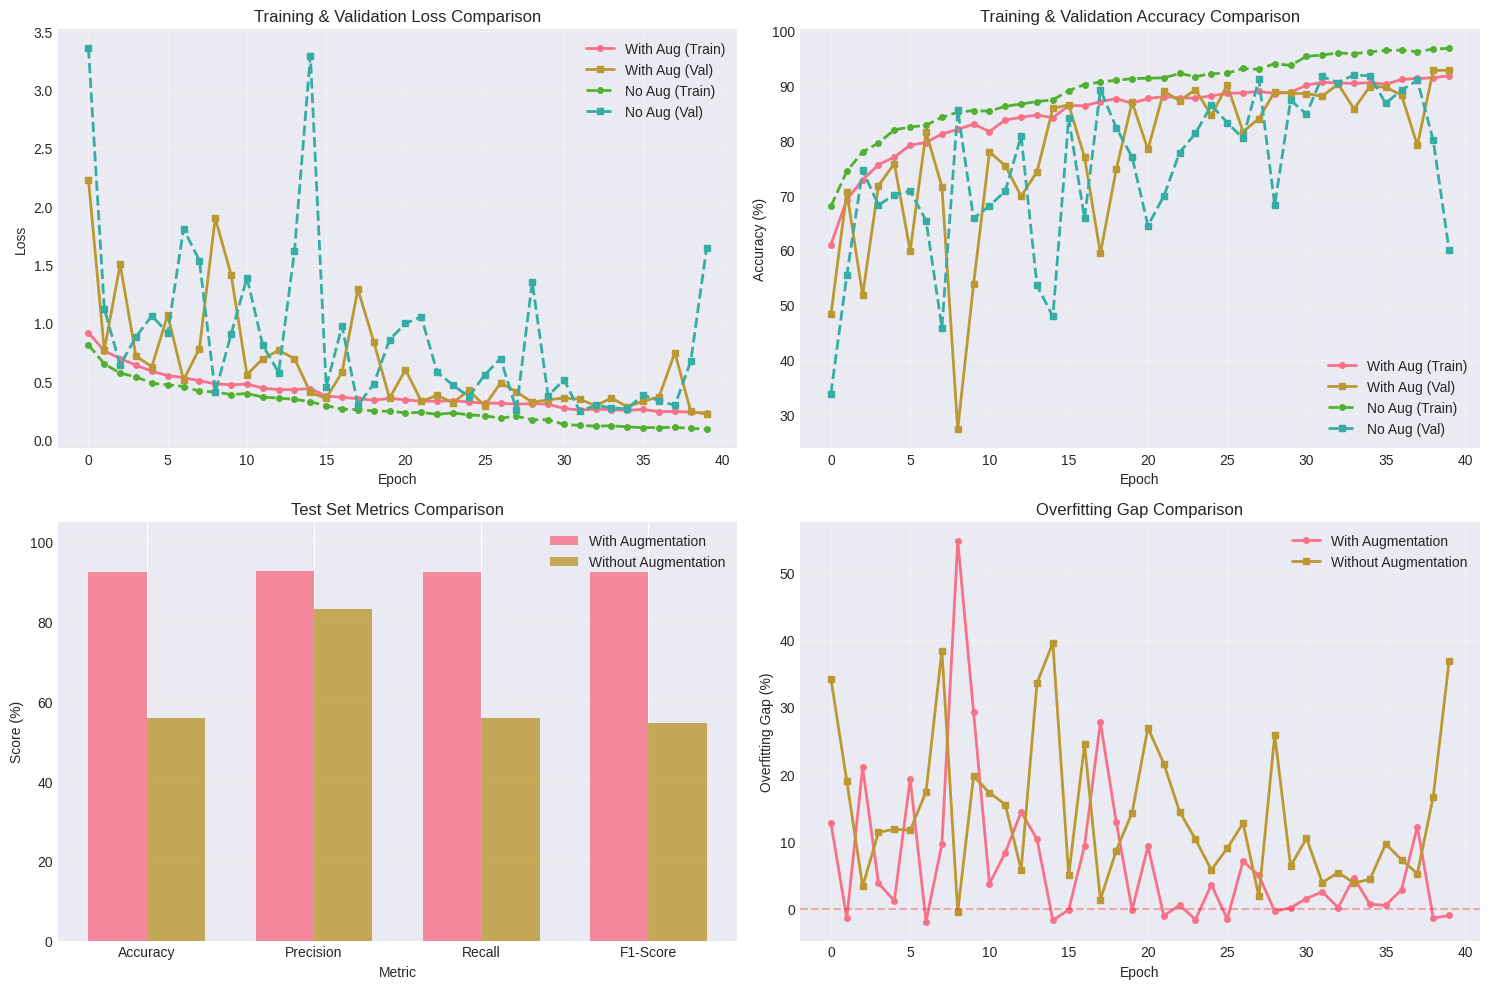

✓ Comparison plot saved → results/plots/training_curves_comparison.png
✓ Comparison visualization complete


In [42]:
# Compare training curves
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Loss comparison
ax1.plot(history['train_loss'], label='With Aug (Train)', marker='o', linewidth=2, markersize=4)
ax1.plot(history['val_loss'], label='With Aug (Val)', marker='s', linewidth=2, markersize=4)
ax1.plot(history_no_aug['train_loss'], label='No Aug (Train)', marker='o', linewidth=2, markersize=4, linestyle='--')
ax1.plot(history_no_aug['val_loss'], label='No Aug (Val)', marker='s', linewidth=2, markersize=4, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss Comparison')
ax1.legend()
ax1.grid(alpha=0.3)

# Accuracy comparison
ax2.plot(history['train_acc'], label='With Aug (Train)', marker='o', linewidth=2, markersize=4)
ax2.plot(history['val_acc'], label='With Aug (Val)', marker='s', linewidth=2, markersize=4)
ax2.plot(history_no_aug['train_acc'], label='No Aug (Train)', marker='o', linewidth=2, markersize=4, linestyle='--')
ax2.plot(history_no_aug['val_acc'], label='No Aug (Val)', marker='s', linewidth=2, markersize=4, linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy Comparison')
ax2.legend()
ax2.grid(alpha=0.3)

# Test metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
with_aug = [results_baseline['accuracy']*100, results_baseline['precision']*100,
           results_baseline['recall']*100, results_baseline['f1']*100]
without_aug = [results_no_aug['accuracy']*100, results_no_aug['precision']*100,
             results_no_aug['recall']*100, results_no_aug['f1']*100]

x = np.arange(len(metrics))
width = 0.35

ax3.bar(x - width/2, with_aug, width, label='With Augmentation', alpha=0.8)
ax3.bar(x + width/2, without_aug, width, label='Without Augmentation', alpha=0.8)
ax3.set_xlabel('Metric')
ax3.set_ylabel('Score (%)')
ax3.set_title('Test Set Metrics Comparison')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([0, 105])

# Overfitting gap comparison
epochs_with = len(history['train_acc'])
epochs_without = len(history_no_aug['train_acc'])
gap_with = np.array(history['train_acc']) - np.array(history['val_acc'])
gap_without = np.array(history_no_aug['train_acc']) - np.array(history_no_aug['val_acc'])

ax4.plot(gap_with, label='With Augmentation', marker='o', linewidth=2, markersize=4)
ax4.plot(gap_without, label='Without Augmentation', marker='s', linewidth=2, markersize=4)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Overfitting Gap (%)')
ax4.set_title('Overfitting Gap Comparison')
ax4.legend()
ax4.grid(alpha=0.3)
ax4.axhline(y=0, color='r', linestyle='--', alpha=0.3)

plt.tight_layout()
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(PLOTS_DIR / 'training_curves_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'✓ Comparison plot saved → {PLOTS_DIR / "training_curves_comparison.png"}')

print('✓ Comparison visualization complete')

---

## 12. Week 2 Summary & Conclusions

In [43]:
print("\n" + "="*80)
print("WEEK 2 PROJECT SUMMARY")
print("="*80)

print("\n✅ COMPLETED TASKS:")
print("")
print("  1. DATA PREPROCESSING PIPELINE")
print(f"     - Resizing: 512×512 → 224×224 (20x memory reduction)")
print(f"     - Normalization: [-1, 1] range (standardized inputs)")
print(f"     - Train/Val/Test split: 70/15/15 (stratified)")
print(f"     - PyTorch DataLoader: batch_size=32, num_workers=4")

print("\n  2. DATA AUGMENTATION STRATEGY")
print(f"     - Random Rotation: ±20°")
print(f"     - Horizontal Flip: 50% probability")
print(f"     - ColorJitter: ±20% brightness/contrast")
print(f"     - Applied only to training set (not val/test)")

print("\n  3. CNN BASELINE MODEL")
print(f"     - Architecture: 4 Conv blocks + FC layers")
print(f"     - Parameters: {total_params:,}")
print(f"     - BatchNorm: Applied after each Conv layer")
print(f"     - Dropout: 50% in FC layer")

print("\n  4. TRAINING PIPELINE")
print(f"     - Optimizer: Adam (lr=0.001)")
print(f"     - Loss: CrossEntropyLoss")
print(f"     - Scheduler: StepLR (step=15, gamma=0.5)")
print(f"     - Epochs trained: {len(history['train_acc'])}")
print(f"     - Training time: {training_time/60:.1f} minutes")
print(f"     - Early stopping: patience=10")

print("\n  5. MODEL EVALUATION")
print(f"     - Test Accuracy: {results_baseline['accuracy']*100:.2f}%")
print(f"     - Confusion Matrix: Generated")
print(f"     - Per-class metrics: Calculated")
print(f"     - Classification report: Generated")

print("\n  6. OVERFITTING ANALYSIS")
print(f"     - Final Train Acc: {history['train_acc'][-1]:.2f}%")
print(f"     - Final Val Acc: {history['val_acc'][-1]:.2f}%")
print(f"     - Train-Val Gap: {abs(history['train_acc'][-1] - history['val_acc'][-1]):.2f}%")
if abs(history['train_acc'][-1] - history['val_acc'][-1]) < 5:
    print(f"     - Status: ✓ Minimal overfitting")
elif abs(history['train_acc'][-1] - history['val_acc'][-1]) < 10:
    print(f"     - Status: ⚠ Moderate overfitting")
else:
    print(f"     - Status: ❌ Severe overfitting")

print("\n  7. EXPERIMENT COMPARISON")
print(f"     - Model 1 (WITH Aug): {results_baseline['accuracy']*100:.2f}% accuracy")
print(f"     - Model 2 (NO Aug): {results_no_aug['accuracy']*100:.2f}% accuracy")
print(f"     - Improvement: {(results_baseline['accuracy'] - results_no_aug['accuracy'])*100:+.2f}%")
print(f"     - Overfitting reduction: {overfitting_reduction:+.2f}%")

print("\n" + "="*80)
print("WEEK 2 DELIVERABLES")
print("="*80)
print("\n✅ Generated:")
print(f"  - notebooks/week_02.ipynb (this notebook)")
print(f"  - Training curves (loss & accuracy)")
print(f"  - Confusion matrix (test set)")
print(f"  - Classification report")
print(f"  - Overfitting analysis")
print(f"  - Experiment comparison")
print(f"  - reports/week_02.md (to be created)")


WEEK 2 PROJECT SUMMARY

✅ COMPLETED TASKS:

  1. DATA PREPROCESSING PIPELINE
     - Resizing: 512×512 → 224×224 (20x memory reduction)
     - Normalization: [-1, 1] range (standardized inputs)
     - Train/Val/Test split: 70/15/15 (stratified)
     - PyTorch DataLoader: batch_size=32, num_workers=4

  2. DATA AUGMENTATION STRATEGY
     - Random Rotation: ±20°
     - Horizontal Flip: 50% probability
     - ColorJitter: ±20% brightness/contrast
     - Applied only to training set (not val/test)

  3. CNN BASELINE MODEL
     - Architecture: 4 Conv blocks + FC layers
     - Parameters: 523,012
     - BatchNorm: Applied after each Conv layer
     - Dropout: 50% in FC layer

  4. TRAINING PIPELINE
     - Optimizer: Adam (lr=0.001)
     - Loss: CrossEntropyLoss
     - Scheduler: StepLR (step=15, gamma=0.5)
     - Epochs trained: 40
     - Training time: 23.4 minutes
     - Early stopping: patience=10

  5. MODEL EVALUATION
     - Test Accuracy: 92.31%
     - Confusion Matrix: Generated
     

---

## 13. Week 3 Preview

### What's Next: Transfer Learning & Advanced Models

In [45]:
print("\n" + "="*80)
print("WEEK 3 PREVIEW: TRANSFER LEARNING & GRAD-CAM")
print("="*80)

print("\n📌 Week 3 Objectives:")
print("\n  1. TRANSFER LEARNING")
print("     - Load pretrained ResNet50 from ImageNet")
print("     - Fine-tune final layers for brain tumor classification")
print("     - Compare with baseline CNN (Week 2)")
print("     - Expected: 95%+ accuracy")

print("\n  2. MODEL ARCHITECTURES")
print("     - ResNet50: 50-layer deep residual network")
print("     - EfficientNet-B0/B1: Efficient scaling")
print("     - Ensemble: Multiple models combined")

print("\n  3. GRAD-CAM VISUALIZATION")
print("     - Visualize what model learned")
print("     - Highlight tumor regions")
print("     - Explain model predictions")
print("     - Medical interpretability")

print("\n  4. HYPERPARAMETER TUNING")
print("     - Learning rate optimization")
print("     - Batch size experiments")
print("     - Unfreezing strategies")

print("\n🎯 Performance Target:")
print("     Week 1 (EDA)")
print(f"     Week 2 (CNN): {results_baseline['accuracy']*100:.0f}% (current)")
print("     Week 3 (Transfer): 95%+ (goal)")
print("     Week 4 (Advanced): 97%+ (target)")

print("\n" + "="*80)


WEEK 3 PREVIEW: TRANSFER LEARNING & GRAD-CAM

📌 Week 3 Objectives:

  1. TRANSFER LEARNING
     - Load pretrained ResNet50 from ImageNet
     - Fine-tune final layers for brain tumor classification
     - Compare with baseline CNN (Week 2)
     - Expected: 95%+ accuracy

  2. MODEL ARCHITECTURES
     - ResNet50: 50-layer deep residual network
     - EfficientNet-B0/B1: Efficient scaling
     - Ensemble: Multiple models combined

  3. GRAD-CAM VISUALIZATION
     - Visualize what model learned
     - Highlight tumor regions
     - Explain model predictions
     - Medical interpretability

  4. HYPERPARAMETER TUNING
     - Learning rate optimization
     - Batch size experiments
     - Unfreezing strategies

🎯 Performance Target:
     Week 1 (EDA)
     Week 2 (CNN): 92% (current)
     Week 3 (Transfer): 95%+ (goal)
     Week 4 (Advanced): 97%+ (target)

